Logs
- [2025/11/16]    
  Test `scikit-opt` for PSO algorithm with vectorized feature

- [2025/11/20]    
  We test with the benchmark function $F_1$ from `pso-vectorized.ipynb.   
  If we look to the source code of 
  [`PSO.py`](https://github.com/guofei9987/scikit-opt/blob/master/sko/PSO.py#L13) of `scikit-opt`, it is already 
  vectorized by design.

In [1]:
import sko
import matplotlib.pyplot as plt
import numpy as np

from sko.PSO import PSO
from sko.tools import set_run_mode
from types import MethodType, FunctionType

In [2]:
sko.__version__

'0.6.6'

In [3]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16,
  'grid.alpha': 0.25})

Define your problem

In [4]:
def obj_func_1(x, o, D, M, a=0.5, b=3, k_max=20):
  f_bias_11 = 90
  z = np.dot((x - o), M)

  k_arr = np.arange(k_max + 1)

  # return a**k_arr 
  term1 = np.sum((a**k_arr)[:, np.newaxis, np.newaxis, np.newaxis]\
    *np.cos((2.*np.pi*b**k_arr)[:, np.newaxis, np.newaxis, np.newaxis] * (z + 0.5)), axis=0)
  term2 = D*np.sum(a**k_arr * np.cos(2.*np.pi*b**k_arr * 0.5), axis=0)
  return np.sum(term1, axis=-1) - term2 + f_bias_11

In [5]:
M_D2 = np.zeros((2, 2)) 
with open("../cec-2005/weierstrass_M_D2.txt") as fp:
  for i, line in enumerate(fp):
    M_D2[i] = np.array(list(map(float, line.strip().split())))

o_arr = None
with open("../cec-2005/weierstrass_data.txt") as fp:
  for i, line in enumerate(fp):
    o_arr = np.array(list(map(float, line.strip().split())))

display(M_D2)
display(o_arr)

array([[ 0.44632867,  1.58946328],
       [-3.93103413, -2.79667085]])

array([-0.1367,  0.1186, -0.0968,  0.0237, -0.2933, -0.0478,  0.3518,
        0.3579, -0.0586, -0.0375,  0.253 ,  0.3165,  0.3974,  0.3813,
        0.1718, -0.2854,  0.0849, -0.18  , -0.0942, -0.1684, -0.1939,
       -0.0154,  0.198 , -0.1252,  0.2211, -0.0536, -0.2085,  0.3883,
       -0.2305,  0.1972,  0.1802, -0.2742,  0.3224,  0.2133,  0.116 ,
       -0.3053,  0.337 ,  0.2232, -0.0619,  0.0743, -0.1337, -0.2071,
        0.2378, -0.1349, -0.0009, -0.2858,  0.1892,  0.0775, -0.3299,
       -0.3864,  0.029 ,  0.1797, -0.3591,  0.2299,  0.2227, -0.0747,
        0.2258, -0.0291, -0.055 ,  0.344 ,  0.0219, -0.3578,  0.3695,
       -0.0036,  0.1446,  0.0133, -0.3803,  0.0483, -0.0406,  0.1314,
       -0.3729, -0.1127, -0.1502, -0.1911, -0.3004, -0.1845, -0.1738,
        0.0771, -0.3186,  0.2763, -0.1197, -0.3663,  0.1649,  0.205 ,
        0.0431,  0.0131, -0.1709,  0.3491, -0.1357,  0.1072,  0.3958,
       -0.2918,  0.1065, -0.3617,  0.0621, -0.0183,  0.0449,  0.3748,
       -0.3578, -0.1

In [6]:
D = 2
o_tensor = o_arr[np.newaxis, np.newaxis, :D]
F_1_min = obj_func_1(o_tensor, o_tensor, D, M_D2)
F_1_min

array([[90.]])

In [7]:
def func(x):
  D = 2
  
  o_sol = o_arr[:D][np.newaxis]
  M_tensor = M_D2[np.newaxis, :, :]

  return obj_func_1([x], o_sol, D, M_tensor)

do PSO

In [8]:
set_run_mode(func, "vectorization")
pso = PSO(func=func, n_dim=2, pop=50, max_iter=100, 
          lb=[-0.5, -0.5], ub=[0.5,0.5], w=0.5, c1=0.3, c2=0.3)
pso.run()
# -- general best location for all particles in history
print(f"best_x is ", pso.gbest_x)
# -- general best image for all particles in history
print(f"best_y is ", pso.gbest_y)

best_x is  [-0.1367  0.1186]
best_y is  [90.]


plot the result

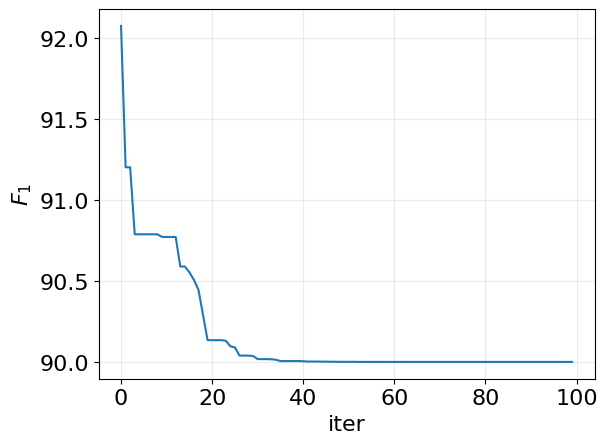

In [9]:
fig, ax = plt.subplots()

ax.plot(pso.gbest_y_hist)

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.grid("on")

plt.show()

Test for $N$ runs

In [10]:
getattr(func, 'mode', 'others')

'vectorization'

In [11]:
iter_max = 100

N_particles = 50
# N_particles = 400
# N_particles = 1000
# N_particles = 5000

num_of_runs = 1000      # 30 secs / 50 particles
                        # 1 min 22 secs / 400 particles
                        # 3 min 5 secs / 1000 particles
                        # 15 mins 58 secs / 5000 particles

pso_runs_obj = []

for i in range(num_of_runs):
  print(f"run: {i}")
  set_run_mode(func, "vectorization")
  pso = PSO(func=func, n_dim=2, pop=N_particles, max_iter=iter_max, 
            lb=[-0.5, -0.5], ub=[0.5,0.5], w=0.5, c1=0.3, c2=0.3)
  pso.run()
  pso_runs_obj.append(pso)

run: 0
run: 1
run: 2
run: 3
run: 4
run: 5
run: 6
run: 7
run: 8
run: 9
run: 10
run: 11
run: 12
run: 13
run: 14
run: 15
run: 16
run: 17
run: 18
run: 19
run: 20
run: 21
run: 22
run: 23
run: 24
run: 25
run: 26
run: 27
run: 28
run: 29
run: 30
run: 31
run: 32
run: 33
run: 34
run: 35
run: 36
run: 37
run: 38
run: 39
run: 40
run: 41
run: 42
run: 43
run: 44
run: 45
run: 46
run: 47
run: 48
run: 49
run: 50
run: 51
run: 52
run: 53
run: 54
run: 55
run: 56
run: 57
run: 58
run: 59
run: 60
run: 61
run: 62
run: 63
run: 64
run: 65
run: 66
run: 67
run: 68
run: 69
run: 70
run: 71
run: 72
run: 73
run: 74
run: 75
run: 76
run: 77
run: 78
run: 79
run: 80
run: 81
run: 82
run: 83
run: 84
run: 85
run: 86
run: 87
run: 88
run: 89
run: 90
run: 91
run: 92
run: 93
run: 94
run: 95
run: 96
run: 97
run: 98
run: 99
run: 100
run: 101
run: 102
run: 103
run: 104
run: 105
run: 106
run: 107
run: 108
run: 109
run: 110
run: 111
run: 112
run: 113
run: 114
run: 115
run: 116
run: 117
run: 118
run: 119
run: 120
run: 121
run: 122
run

History plots for many runs

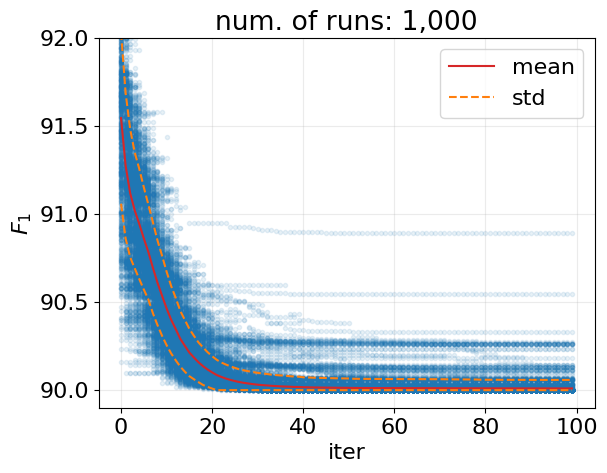

In [12]:
fig, ax = plt.subplots()

temp_sum = np.zeros(iter_max)
for pso in pso_runs_obj:
  # history_g_best = pso.gbest_x
  g_best_F1 = pso.gbest_y_hist
  ax.plot(g_best_F1, color="tab:blue", alpha=0.1, 
          linestyle="None", marker=".")
  temp_sum += np.array(g_best_F1).flatten()

runs_mean = temp_sum/num_of_runs

runs_std = np.zeros(iter_max)
temp_var = np.zeros(iter_max)
for pso in pso_runs_obj:
  g_best_F1 = pso.gbest_y_hist
  temp_var += (np.array(g_best_F1).flatten() - runs_mean)**2

runs_std = np.sqrt(temp_var/num_of_runs)
ax.plot(runs_mean, color="tab:red", label="mean")
ax.plot(runs_mean + runs_std, color="tab:orange", label="std", linestyle="--")

lower_bound = runs_mean - runs_std
lower_bound[lower_bound < 90] = 90
ax.plot(lower_bound, color="tab:orange", label=None, linestyle="--")

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.set_ylim([89.9, 92])

ax.set_title(f"num. of runs: {num_of_runs:,}")
ax.grid("on")
ax.legend(loc="best")


plt.show(fig)

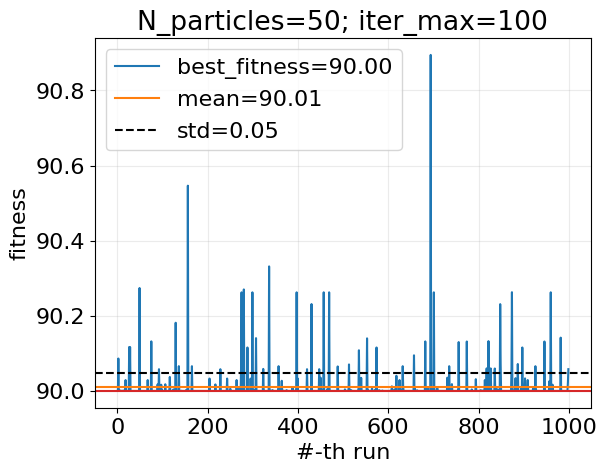

In [14]:
fig, ax = plt.subplots()

runs_best_fitness = np.array([pso.gbest_y[0] for pso in pso_runs_obj])
ax.plot(runs_best_fitness, label=f"best_fitness={np.min(runs_best_fitness):.2f}")

# -- average
mean_runs_best_fitness = np.mean(runs_best_fitness)
ax.axhline(mean_runs_best_fitness, color="tab:orange", 
            label=f"mean={mean_runs_best_fitness:.2f}")
stddev_runs_best_fitness = np.std(runs_best_fitness)
ax.axhline(F_1_min + stddev_runs_best_fitness, color="k",
            linestyle="--", label=f"std={stddev_runs_best_fitness:.2f}")

# -- ground truth
ax.axhline(F_1_min, color="tab:red")

ax.grid("on")
ax.set_xlabel("#-th run")
ax.set_ylabel("fitness")
ax.set_title(f"N_particles={N_particles}; iter_max={iter_max}")
ax.legend(loc="best")

plt.show(fig)